# Notebook 03 — Case Retrieval
## Sistem CBR Putusan Kasasi Peradilan Anak ABH · Mahkamah Agung RI

Notebook ini menjalankan **Tahap 3 CBR (Case Retrieval)**:
membangun representasi vektor dan menemukan kasus lama yang paling mirip dengan kasus baru.

| Pendekatan | Model | Metode Retrieval |
|------------|-------|-----------------|
| **Statistik** | TF-IDF (unigram + bigram) | Cosine Similarity |
| **Machine Learning** | SVM (kernel linear, balanced) | Klasifikasi Outcome |
| **Semantik** | IndoBERT mean pooling | Cosine Similarity |

**Split data:** Train 80% / Test 20% (stratified, `random_state=42`)

| Input | Output |
|-------|--------|
| `data/case_base.json` | `data/retrieval_results.json` |
| `data/bert_embeddings.npy` | `data/retrieval_comparison.csv` |
| — | `data/eval/queries.json` |
| — | `data/eval/test_case_ids.json` |


## 1 · Install & Import

In [1]:
# Jalankan sekali jika paket belum tersedia
# !pip install transformers torch scikit-learn pandas numpy --quiet

import json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    cross_val_score, StratifiedKFold, train_test_split
)
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# ── Resolusi ROOT_DIR ───────────────────────────────────────────────
# Agar path data/ tetap valid baik notebook dijalankan dari root project
# maupun dari dalam folder notebook/ (working directory kernel kadang
# ikut lokasi file .ipynb). Cari ke atas folder yang punya subfolder data/;
# kalau belum ada (run pertama kali), fallback: naik 1 level jika cwd = "notebook".
def _tentukan_root_dir() -> Path:
    cwd = Path.cwd().resolve()
    p = cwd
    for _ in range(4):
        if (p / "data").exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    return cwd.parent if cwd.name.lower() in ("notebook", "notebooks") else cwd

ROOT_DIR = _tentukan_root_dir()

DATA_DIR      = ROOT_DIR / 'data'
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR    = ROOT_DIR / 'data' / 'eval'
METRICS_DIR = ROOT_DIR / 'data' / 'eval' / 'metrics'
VIZ_DIR     = ROOT_DIR / 'data' / 'eval' / 'visualisasi'
METRICS_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print('Import selesai.')

Import selesai.


## 2 · Load Case Base

In [2]:
with open(PROCESSED_DIR / 'case_base.json', encoding='utf-8') as f:
    case_base = json.load(f)

df = pd.DataFrame(case_base)

print(f'Total kasus    : {len(df)}')
print(f'Kolom tersedia : {list(df.columns)}')
print()
print('Distribusi outcome kasasi:')
print(df['outcome_kasasi'].value_counts().to_string())
print()
# Verifikasi field struktural yang dihasilkan notebook 02
for field in ['duduk_perkara', 'memori_kasasi', 'pertimbangan_hukum', 'word_count']:
    if field in df.columns:
        pct = df[field].astype(str).str.strip().str.len().gt(0).mean() * 100
        print(f'  {field:<25} {pct:.1f}% terisi')
    else:
        print(f'  {field:<25} [TIDAK ADA — periksa notebook 02]')

Total kasus    : 150
Kolom tersedia : ['case_id', 'file_pdf', 'nomor_perkara', 'tahun', 'jenis_perkara', 'pasal_didakwakan', 'terdakwa', 'vonis', 'amar_putusan', 'outcome_kasasi', 'word_count', 'char_count', 'duduk_perkara', 'memori_kasasi', 'pertimbangan_hukum', 'teks_lengkap']

Distribusi outcome kasasi:
outcome_kasasi
DITOLAK             124
TIDAK TERDETEKSI     11
DIPERBAIKI           10
DIKABULKAN            5

  duduk_perkara             100.0% terisi
  memori_kasasi             99.3% terisi
  pertimbangan_hukum        100.0% terisi
  word_count                100.0% terisi


## 3 · [Poin c.i] Persiapan Fitur Teks

Teks representasi (`teks_query`) dibangun dari gabungan field struktural putusan kasasi MA.
`memori_kasasi` diulang dua kali karena merupakan argumen paling informatif untuk CBR similarity.

| Field | Bobot | Alasan |
|-------|-------|--------|
| `pasal_didakwakan` | Tinggi | Menentukan jenis perkara |
| `memori_kasasi` | **Tertinggi** (2×) | Argumen spesifik — kunci CBR similarity |
| `duduk_perkara` | Sedang | Konteks kronologi |
| `amar_putusan` | Tinggi | Outcome yang dicari |
| `vonis` | Sedang | Detail hukuman |
| `pertimbangan_hukum` | Sedang | Reasoning hakim (dibatasi 300 karakter) |


In [3]:
def bersihkan_field(teks, max_len=None):
    """
    Bersihkan field teks dari case_base.json.
    - Buang baris header metadata '# CASE_ID', '# FILENAME' dst.
    - Normalisasi whitespace.
    """
    if not teks:
        return ''
    baris = [b for b in str(teks).splitlines() if not b.startswith('#')]
    hasil = ' '.join(' '.join(baris).split())
    return hasil[:max_len] if max_len else hasil


def buat_teks_query(row):
    """
    Bangun representasi teks gabungan untuk retrieval.
    memori_kasasi diulang 2x agar bobotnya lebih tinggi dalam TF-IDF.
    """
    pasal        = bersihkan_field(row.get('pasal_didakwakan', '')  or '')
    memori       = bersihkan_field(row.get('memori_kasasi', '')     or '', max_len=800)
    duduk        = bersihkan_field(row.get('duduk_perkara', '')     or '', max_len=400)
    amar         = bersihkan_field(row.get('amar_putusan', '')      or '')
    vonis        = bersihkan_field(row.get('vonis', '')             or '')
    pertimbangan = bersihkan_field(row.get('pertimbangan_hukum','') or '', max_len=300)
    bagian = [pasal, memori, memori, duduk, amar, vonis, pertimbangan]
    return ' '.join(b for b in bagian if b.strip())


df['teks_query'] = df.apply(buat_teks_query, axis=1)

# Label untuk klasifikasi SVM — TIDAK TERDETEKSI dikecualikan dari training
label_map = {'DITOLAK': 0, 'DIKABULKAN': 1, 'DIPERBAIKI': 2, 'TIDAK TERDETEKSI': -1}
df['label'] = df['outcome_kasasi'].map(label_map)

df_valid = df[df['label'] >= 0].reset_index(drop=True)
print(f'Panjang teks_query (rata-rata)  : {df["teks_query"].str.len().mean():.0f} karakter')
print(f'Kasus dengan label valid        : {len(df_valid)}')
print(f'Kasus TIDAK TERDETEKSI (exclude): {len(df) - len(df_valid)}')

Panjang teks_query (rata-rata)  : 1710 karakter
Kasus dengan label valid        : 139
Kasus TIDAK TERDETEKSI (exclude): 11


## 4 · [Poin c.i — Statistik] Representasi Vektor TF-IDF

`TfidfVectorizer` dengan `ngram_range=(1,2)` dan `sublinear_tf=True`:
- **Unigram + bigram**: menangkap pasangan kata khas hukum ('menolak kasasi', 'mengabulkan permohonan')
- **sublinear_tf**: normalisasi logaritmik agar token frekuensi tinggi tidak mendominasi


In [4]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
)
tfidf_matrix = tfidf.fit_transform(df['teks_query'])

print(f'TF-IDF matrix : {tfidf_matrix.shape}')
print(f'Vocab size    : {len(tfidf.vocabulary_):,} fitur')

# Tampilkan 10 fitur dengan skor IDF tertinggi (paling diskriminatif)
idf_vals   = tfidf.idf_
feat_names = tfidf.get_feature_names_out()
top10_idx  = idf_vals.argsort()[-10:][::-1]
print()
print('10 fitur TF-IDF paling diskriminatif (IDF tertinggi):')
for i in top10_idx:
    print(f'  {feat_names[i]:<35} IDF={idf_vals[i]:.4f}')

TF-IDF matrix : (150, 5000)
Vocab size    : 5,000 fitur

10 fitur TF-IDF paling diskriminatif (IDF tertinggi):
  025                                 IDF=5.3241
  yusuf                               IDF=5.3241
  yuridis pada                        IDF=5.3241
  yuridis dengan                      IDF=5.3241
  025 dari                            IDF=5.3241
  yudha pkratama                      IDF=5.3241
  yudha                               IDF=5.3241
  10051                               IDF=5.3241
  10051 pid                           IDF=5.3241
  10i                                 IDF=5.3241


### 4a · Fungsi `retrieve_tfidf()`

In [5]:
def retrieve_tfidf(query_teks: str, top_k: int = 5, exclude_idx=None) -> list:
    """
    Retrieve top-k kasus paling mirip menggunakan TF-IDF + Cosine Similarity.

    Parameters
    ----------
    query_teks  : str — teks representasi kasus baru
    top_k       : int — jumlah kasus yang dikembalikan
    exclude_idx : int — indeks yang dikecualikan (untuk evaluasi LOO/self-exclude)

    Returns
    -------
    list[dict] — hasil retrieval terurut dari similarity tertinggi
    """
    # 1) Pre-process & vectorize query
    q_vec = tfidf.transform([query_teks])

    # 2) Hitung cosine similarity dengan semua case vectors
    skor  = cosine_similarity(q_vec, tfidf_matrix).flatten()

    # 3) Exclude diri sendiri (jika evaluasi leave-one-out)
    if exclude_idx is not None:
        skor[exclude_idx] = -1.0

    # 4) Ambil top-k berdasarkan similarity
    top_idx = skor.argsort()[::-1][:top_k]

    return [{
        'case_id'         : df.iloc[idx]['case_id'],
        'nomor_perkara'   : df.iloc[idx]['nomor_perkara'],
        'outcome_kasasi'  : df.iloc[idx]['outcome_kasasi'],
        'vonis'           : df.iloc[idx]['vonis'],
        'skor_similarity' : round(float(skor[idx]), 4),
        'metode'          : 'TF-IDF',
    } for idx in top_idx]


# ── Quick test ─────────────────────────────────────────────────────────
print('=== Contoh Retrieval TF-IDF ===')
print(f'Query: {df.iloc[0]["case_id"]} | outcome: {df.iloc[0]["outcome_kasasi"]}')
print()
hasil_tfidf = retrieve_tfidf(df.iloc[0]['teks_query'], top_k=5, exclude_idx=0)
for r in hasil_tfidf:
    print(f'  [{r["skor_similarity"]:.4f}] {r["case_id"]:12} | {r["outcome_kasasi"]:12} | {str(r["vonis"])[:40]}')

=== Contoh Retrieval TF-IDF ===
Query: case_001 | outcome: DITOLAK

  [0.4826] case_124     | DITOLAK      | Lembaga Pembinaan Khusus Anak (LPKA) Kel
  [0.2081] case_134     | DITOLAK      | pidana penjara selama 6 (enam) bulan
  [0.2081] case_120     | DIPERBAIKI   | pidana penjara selama 8 (delapan) bulan
  [0.2070] case_009     | DITOLAK      | pidana penjara selama 1 (satuI) tahun
  [0.2058] case_070     | DITOLAK      | pidana penjara selama 4 (empat) bulan


## 5 · [Poin c.ii — Machine Learning] TF-IDF + SVM

SVM dilatih untuk memprediksi `outcome_kasasi` dari representasi TF-IDF.
`class_weight='balanced'` untuk menangani dominasi kelas DITOLAK (~89%).

**Split:** Train 80% / Test 20%, stratified, `random_state=42`.


In [6]:
X = df_valid['teks_query'].to_numpy(dtype=str)
y = df_valid['outcome_kasasi'].to_numpy(dtype=str)

kelas_counts  = df_valid['outcome_kasasi'].value_counts()
bisa_stratify = (kelas_counts >= 2).all()

print('Distribusi kelas (df_valid):')
print(kelas_counts.to_string())
print(f'\nStratify dipakai: {bisa_stratify}')

# ── Train/Test Split 80:20 ───────────────────────────────────────────
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_valid.index.to_numpy(),
    test_size=0.2,
    random_state=42,
    stratify=(y if bisa_stratify else None),
)

print(f'\nTrain : {len(X_train)} kasus')
print(f'Test  : {len(X_test)}  kasus')
print('\nDistribusi train:')
for k, v in zip(*np.unique(y_train, return_counts=True)):
    print(f'  {k}: {v}')
print('Distribusi test:')
for k, v in zip(*np.unique(y_test, return_counts=True)):
    print(f'  {k}: {v}')

Distribusi kelas (df_valid):
outcome_kasasi
DITOLAK       124
DIPERBAIKI     10
DIKABULKAN      5

Stratify dipakai: True

Train : 111 kasus
Test  : 28  kasus

Distribusi train:
  DIKABULKAN: 4
  DIPERBAIKI: 8
  DITOLAK: 99
Distribusi test:
  DIKABULKAN: 1
  DIPERBAIKI: 2
  DITOLAK: 25


In [7]:
# SVM Pipeline: TF-IDF → SVM (linear kernel, balanced weight)
pipe_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)),
    ('svm',   SVC(kernel='linear', C=1.0, probability=True,
                  random_state=42, class_weight='balanced')),
])

# ── Cross-validation pada train set ─────────────────────────────────
min_count = pd.Series(y_train).value_counts().min()
n_folds   = max(2, min(5, int(min_count)))

if min_count < 2:
    print(f'[WARNING] Kelas terkecil di train punya {min_count} anggota — CV dilewati.')
    cv_scores = None
else:
    cv        = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='accuracy')
    print(f'Cross-Validation ({n_folds}-fold) pada Train Set:')
    print(f'  Accuracy : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
    print(f'  Per fold : {[round(s,4) for s in cv_scores]}')

# ── Evaluasi pada Test Set 20% ───────────────────────────────────────
pipe_svm.fit(X_train, y_train)
y_pred_test = pipe_svm.predict(X_test)
label_test  = sorted(set(y_test))

print(f'\nEvaluasi SVM pada Test Set (20%):')
print(classification_report(y_test, y_pred_test, labels=label_test, zero_division=0))

# Re-fit pada seluruh data valid untuk dipakai di fungsi retrieve
pipe_svm.fit(X, y)
print('SVM re-fit pada seluruh data valid (untuk prediksi kasus baru).')

# Simpan indeks test set untuk konsistensi evaluasi di notebook 04 & 05
test_case_ids = set(df_valid.iloc[idx_test]['case_id'].tolist())
print(f'Test set: {len(test_case_ids)} case_id')


def prediksi_svm(query_teks: str):
    """Prediksi outcome kasasi untuk teks kasus baru menggunakan SVM."""
    pred  = pipe_svm.predict([query_teks])[0]
    proba = pipe_svm.predict_proba([query_teks])[0]
    kelas = pipe_svm.classes_
    return pred, dict(zip(kelas, [round(float(p), 4) for p in proba]))

print('prediksi_svm() siap.')

Cross-Validation (4-fold) pada Train Set:
  Accuracy : 0.8919 (+/- 0.0017)
  Per fold : [np.float64(0.8929), np.float64(0.8929), np.float64(0.8929), np.float64(0.8889)]

Evaluasi SVM pada Test Set (20%):
              precision    recall  f1-score   support

  DIKABULKAN       1.00      1.00      1.00         1
  DIPERBAIKI       0.00      0.00      0.00         2
     DITOLAK       0.93      1.00      0.96        25

    accuracy                           0.93        28
   macro avg       0.64      0.67      0.65        28
weighted avg       0.86      0.93      0.89        28

SVM re-fit pada seluruh data valid (untuk prediksi kasus baru).
Test set: 28 case_id
prediksi_svm() siap.


## 6 · [Poin c.i — Semantik] IndoBERT Sentence Embedding

IndoBERT (`indobenchmark/indobert-base-p1`) menghasilkan representasi semantik
yang memahami konteks dan makna bahasa Indonesia.

**Mean pooling** digunakan (bukan `[CLS]`) karena lebih robust untuk teks panjang:
merata-ratakan semua token non-padding menghasilkan representasi yang lebih stabil
dibandingkan satu token CLS saja.


In [8]:
from transformers import AutoTokenizer, AutoModel
import torch

MODEL_NAME     = 'indobenchmark/indobert-base-p1'
print(f'Loading {MODEL_NAME} ...')

tokenizer_bert = AutoTokenizer.from_pretrained(MODEL_NAME)
model_bert     = AutoModel.from_pretrained(MODEL_NAME)
model_bert.eval()

device     = 'cuda' if torch.cuda.is_available() else 'cpu'
model_bert = model_bert.to(device)
print(f'Model siap | device: {device}')


def mean_pooling(model_output, attention_mask):
    """
    Mean pooling atas semua token (kecuali padding).
    Lebih robust dari [CLS] untuk teks panjang — representasi keseluruhan kalimat.
    """
    token_embeddings = model_output.last_hidden_state        # (batch, seq_len, hidden)
    mask_expanded    = attention_mask.unsqueeze(-1).float()  # (batch, seq_len, 1)
    sum_embeddings   = (token_embeddings * mask_expanded).sum(dim=1)
    sum_mask         = mask_expanded.sum(dim=1).clamp(min=1e-9)
    return (sum_embeddings / sum_mask).cpu().numpy()


def get_embedding(teks: str, max_length: int = 512) -> np.ndarray:
    """Embedding mean-pooled IndoBERT untuk satu teks."""
    inputs = tokenizer_bert(
        teks, return_tensors='pt', truncation=True,
        max_length=max_length, padding=True,
    ).to(device)
    with torch.no_grad():
        outputs = model_bert(**inputs)
    return mean_pooling(outputs, inputs['attention_mask']).squeeze()


def get_embeddings_batch(teks_list: list, batch_size: int = 8) -> np.ndarray:
    """Proses embedding dalam batch untuk menghindari OOM."""
    all_embeddings = []
    for i in range(0, len(teks_list), batch_size):
        batch  = teks_list[i:i + batch_size]
        inputs = tokenizer_bert(
            batch, return_tensors='pt', truncation=True,
            max_length=512, padding=True,
        ).to(device)
        with torch.no_grad():
            outputs = model_bert(**inputs)
        emb = mean_pooling(outputs, inputs['attention_mask'])
        all_embeddings.append(emb)
        n_batch = (len(teks_list) - 1) // batch_size + 1
        print(f'  Batch {i//batch_size + 1}/{n_batch} selesai ({len(batch)} teks)')
    return np.vstack(all_embeddings)


print()
print('Membangun BERT embedding untuk seluruh case base ...')
print('(perkiraan 2-5 menit tergantung GPU/CPU)')
bert_matrix = get_embeddings_batch(df['teks_query'].tolist(), batch_size=8)
print(f'\nIndoBERT matrix shape: {bert_matrix.shape}')

# Simpan embedding ke disk agar tidak perlu recompute
emb_path = PROCESSED_DIR / 'bert_embeddings.npy'
np.save(emb_path, bert_matrix)
print(f'Embedding disimpan -> {emb_path}')

Loading indobenchmark/indobert-base-p1 ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 52179.70it/s]


Model siap | device: cpu

Membangun BERT embedding untuk seluruh case base ...
(perkiraan 2-5 menit tergantung GPU/CPU)
  Batch 1/19 selesai (8 teks)
  Batch 2/19 selesai (8 teks)
  Batch 3/19 selesai (8 teks)
  Batch 4/19 selesai (8 teks)
  Batch 5/19 selesai (8 teks)
  Batch 6/19 selesai (8 teks)
  Batch 7/19 selesai (8 teks)
  Batch 8/19 selesai (8 teks)
  Batch 9/19 selesai (8 teks)
  Batch 10/19 selesai (8 teks)
  Batch 11/19 selesai (8 teks)
  Batch 12/19 selesai (8 teks)
  Batch 13/19 selesai (8 teks)
  Batch 14/19 selesai (8 teks)
  Batch 15/19 selesai (8 teks)
  Batch 16/19 selesai (8 teks)
  Batch 17/19 selesai (8 teks)
  Batch 18/19 selesai (8 teks)
  Batch 19/19 selesai (6 teks)

IndoBERT matrix shape: (150, 768)
Embedding disimpan -> D:\Documents\SEMESTER6\Penalaran Komputer\Tugas 3(31)\data\processed\bert_embeddings.npy


### 6a · Fungsi `retrieve_bert()`

In [9]:
# Load embedding dari file (jalankan jika kernel restart)
# bert_matrix = np.load(PROCESSED_DIR / 'bert_embeddings.npy')

def retrieve_bert(query_teks: str, top_k: int = 5, exclude_idx=None) -> list:
    """
    Retrieve top-k kasus paling mirip menggunakan IndoBERT + Cosine Similarity.

    Parameters
    ----------
    query_teks  : str — teks representasi kasus baru
    top_k       : int — jumlah kasus yang dikembalikan
    exclude_idx : int — indeks yang dikecualikan (untuk evaluasi self-exclude)

    Returns
    -------
    list[dict] — hasil retrieval terurut dari similarity tertinggi
    """
    # 1) Pre-process & embed query
    q_emb = get_embedding(query_teks).reshape(1, -1)

    # 2) Hitung cosine similarity dengan seluruh case vectors
    skor = cosine_similarity(q_emb, bert_matrix).flatten()

    # 3) Exclude diri sendiri
    if exclude_idx is not None:
        skor[exclude_idx] = -1.0

    # 4) Ambil top-k
    top_idx = skor.argsort()[::-1][:top_k]

    return [{
        'case_id'         : df.iloc[idx]['case_id'],
        'nomor_perkara'   : df.iloc[idx]['nomor_perkara'],
        'outcome_kasasi'  : df.iloc[idx]['outcome_kasasi'],
        'vonis'           : df.iloc[idx]['vonis'],
        'skor_similarity' : round(float(skor[idx]), 4),
        'metode'          : 'IndoBERT',
    } for idx in top_idx]


# ── Quick test ─────────────────────────────────────────────────────────
print('=== Contoh Retrieval IndoBERT ===')
print(f'Query: {df.iloc[0]["case_id"]} | outcome: {df.iloc[0]["outcome_kasasi"]}')
print()
hasil_bert = retrieve_bert(df.iloc[0]['teks_query'], top_k=5, exclude_idx=0)
for r in hasil_bert:
    print(f'  [{r["skor_similarity"]:.4f}] {r["case_id"]:12} | {r["outcome_kasasi"]:12} | {str(r["vonis"])[:40]}')

=== Contoh Retrieval IndoBERT ===
Query: case_001 | outcome: DITOLAK

  [0.9588] case_124     | DITOLAK      | Lembaga Pembinaan Khusus Anak (LPKA) Kel
  [0.9532] case_009     | DITOLAK      | pidana penjara selama 1 (satuI) tahun
  [0.9498] case_053     | DITOLAK      | pidana penjara selama 4 (empat) bulan
  [0.9495] case_070     | DITOLAK      | pidana penjara selama 4 (empat) bulan
  [0.9493] case_088     | DITOLAK      | pidana penjara selama 10 (sepuluh) bulan


## 7 · [Poin c.iv] Fungsi `retrieve()` — Sesuai Spesifikasi Brief

```python
def retrieve(query: str, k: int = 5) -> List[case_id]
```

Implementasi wrapper yang menerima teks query mentah dan mengembalikan list `case_id`.


In [10]:
def retrieve(query: str, k: int = 5, metode: str = 'bert') -> List[str]:
    """
    Retrieve top-k case_id yang paling mirip dengan query kasus baru.

    Parameters
    ----------
    query  : str  — teks kasus baru (ringkasan fakta / pasal / gabungan)
    k      : int  — jumlah kasus yang dikembalikan (default 5)
    metode : str  — 'bert' (default) atau 'tfidf'

    Returns
    -------
    List[str] — list case_id terurut dari similarity tertinggi
    """
    # 1) Pre-process query — normalisasi whitespace
    query = ' '.join(query.split())

    if metode == 'tfidf':
        # 2) Hitung vektor TF-IDF
        q_vec = tfidf.transform([query])
        # 3) Hitung cosine similarity dengan semua case vectors
        skor  = cosine_similarity(q_vec, tfidf_matrix).flatten()
    else:
        # 2) Hitung embedding IndoBERT
        q_emb = get_embedding(query).reshape(1, -1)
        # 3) Hitung cosine similarity dengan semua case vectors
        skor  = cosine_similarity(q_emb, bert_matrix).flatten()

    # 4) Kembalikan top-k case_id
    top_idx = skor.argsort()[::-1][:k]
    return [df.iloc[idx]['case_id'] for idx in top_idx]


# ── Quick test ─────────────────────────────────────────────────────────
contoh_query = df.iloc[0]['teks_query']
print('=== Test fungsi retrieve() ===')
print(f'Query  : {df.iloc[0]["case_id"]} | outcome: {df.iloc[0]["outcome_kasasi"]}')
print()
print(f'TF-IDF : {retrieve(contoh_query, k=5, metode="tfidf")}')
print(f'BERT   : {retrieve(contoh_query, k=5, metode="bert")}')

=== Test fungsi retrieve() ===
Query  : case_001 | outcome: DITOLAK

TF-IDF : ['case_001', 'case_124', 'case_134', 'case_120', 'case_009']
BERT   : ['case_001', 'case_124', 'case_009', 'case_053', 'case_070']


## 8 · [Poin c.v] Generate `data/eval/queries.json`

5–10 query uji dari test set beserta ground-truth `case_id` dan skor similarity.
File ini digunakan oleh notebook 04 (demo manual) dan notebook 05 (evaluasi).

File `test_case_ids.json` juga disimpan agar split 80:20 konsisten di semua notebook.


In [11]:
# Ambil query uji dari TEST SET (bukan train)
# ground_truth_outcome = label outcome kasasi kasus itu sendiri (oracle label dari data)
# ground_truth_tfidf / bert = top-k case_id hasil retrieval (digunakan sebagai proxy
#   evaluasi similarity, bukan anotasi manual)
n_query    = min(10, len(idx_test))
sample_idx = idx_test[:n_query]

queries_eval = []
for i in sample_idx:
    row = df_valid.iloc[i]

    # Temukan posisi kasus ini di df lengkap (untuk exclude_idx yang tepat)
    matches = df.index[df['case_id'] == row['case_id']].tolist()
    exclude = matches[0] if matches else None

    gt_tfidf = retrieve_tfidf(row['teks_query'], top_k=5, exclude_idx=exclude)
    gt_bert  = retrieve_bert(row['teks_query'],  top_k=5, exclude_idx=exclude)

    entry = {
        'query_id'          : f'q{len(queries_eval)+1:03d}',
        'case_id_sumber'    : row['case_id'],
        'nomor_perkara'     : row['nomor_perkara'],
        'outcome_kasasi'    : row['outcome_kasasi'],
        # Simpan teks penuh — tidak dipotong agar retrieval di NB04 akurat
        # (pemotongan [:300] sebelumnya menyebabkan amar putusan sering kosong)
        'query_teks'        : row['teks_query'],
        # ground_truth_tfidf/bert = proxy similarity (top-k retrieved case_id)
        # Catatan metodologi: ini bukan anotasi oracle manual, melainkan hasil
        # retrieval model sendiri yang dipakai sebagai baseline perbandingan.
        # Label oracle yang sesungguhnya adalah 'outcome_kasasi' di atas.
        'ground_truth_tfidf': [r['case_id'] for r in gt_tfidf],
        'ground_truth_bert' : [r['case_id'] for r in gt_bert],
        'skor_tfidf'        : [r['skor_similarity'] for r in gt_tfidf],
        'skor_bert'         : [r['skor_similarity'] for r in gt_bert],
    }
    queries_eval.append(entry)

# ── Simpan queries.json ───────────────────────────────────────────────
out_queries = METRICS_DIR / 'queries.json'
with open(out_queries, 'w', encoding='utf-8') as f:
    json.dump(queries_eval, f, ensure_ascii=False, indent=2)
print(f'queries.json disimpan -> {out_queries} ({len(queries_eval)} query)')
print(f'  query_teks: teks penuh (tidak dipotong)')
print(f'  ground_truth: label oracle = outcome_kasasi | proxy sim = ground_truth_tfidf/bert')

# ── Simpan test_case_ids.json ─────────────────────────────────────────
out_test_ids = METRICS_DIR / 'test_case_ids.json'
with open(out_test_ids, 'w', encoding='utf-8') as f:
    json.dump(sorted(test_case_ids), f, ensure_ascii=False, indent=2)
print(f'test_case_ids.json -> {out_test_ids} ({len(test_case_ids)} kasus)')

# Preview
print()
for q in queries_eval:
    print(f"  {q['query_id']} | {q['case_id_sumber']:12} | {q['outcome_kasasi']}")
    print(f"    TF-IDF top3: {q['ground_truth_tfidf'][:3]}")
    print(f"    BERT   top3: {q['ground_truth_bert'][:3]}")
    print()


queries.json disimpan -> D:\Documents\SEMESTER6\Penalaran Komputer\Tugas 3(31)\data\eval\metrics\queries.json (10 query)
  query_teks: teks penuh (tidak dipotong)
  ground_truth: label oracle = outcome_kasasi | proxy sim = ground_truth_tfidf/bert
test_case_ids.json -> D:\Documents\SEMESTER6\Penalaran Komputer\Tugas 3(31)\data\eval\metrics\test_case_ids.json (28 kasus)

  q001 | case_073     | DITOLAK
    TF-IDF top3: ['case_150', 'case_102', 'case_123']
    BERT   top3: ['case_118', 'case_123', 'case_150']

  q002 | case_038     | DITOLAK
    TF-IDF top3: ['case_039', 'case_029', 'case_005']
    BERT   top3: ['case_039', 'case_037', 'case_005']

  q003 | case_048     | DITOLAK
    TF-IDF top3: ['case_082', 'case_031', 'case_128']
    BERT   top3: ['case_126', 'case_054', 'case_011']

  q004 | case_109     | DITOLAK
    TF-IDF top3: ['case_051', 'case_107', 'case_111']
    BERT   top3: ['case_081', 'case_080', 'case_092']

  q005 | case_125     | DITOLAK
    TF-IDF top3: ['case_113', 'c

## 9 · [Poin c.ii] Evaluasi Retrieval — Test Set 20%

Evaluasi pada **test set** (20% dari `df_valid` yang tidak pernah dilihat model).
Metrik: **Accuracy@1**, **Accuracy@3**, **Accuracy@5** dan Precision/Recall/F1.


In [12]:
def evaluasi_retrieval(metode: str = 'bert', top_k: int = 5):
    """
    Evaluasi retrieval pada test set (80:20 split, random_state=42).

    Parameters
    ----------
    metode : str — 'tfidf' atau 'bert'
    top_k  : int — jumlah kasus retrieved untuk dievaluasi

    Returns
    -------
    dict — metrik evaluasi lengkap
    """
    caseid_to_idx = {row['case_id']: i for i, row in df.iterrows()}

    subset = df_valid[df_valid['case_id'].isin(test_case_ids)]
    total  = len(subset)

    benar_at1 = benar_at3 = benar_at5 = 0
    y_true, y_pred = [], []

    for _, row in subset.iterrows():
        exclude_idx = caseid_to_idx.get(row['case_id'])
        label_asli  = row['outcome_kasasi']

        if metode == 'tfidf':
            hasil = retrieve_tfidf(row['teks_query'], top_k=top_k,
                                   exclude_idx=exclude_idx)
        else:
            hasil = retrieve_bert(row['teks_query'], top_k=top_k,
                                  exclude_idx=exclude_idx)

        outcomes = [h['outcome_kasasi'] for h in hasil
                    if h['outcome_kasasi'] != 'TIDAK TERDETEKSI']

        if outcomes and outcomes[0] == label_asli: benar_at1 += 1
        if label_asli in outcomes[:3]:             benar_at3 += 1
        if label_asli in outcomes[:5]:             benar_at5 += 1

        y_true.append(label_asli)
        y_pred.append(outcomes[0] if outcomes else 'TIDAK TERDETEKSI')

    labels = sorted(set(y_true))
    hasil_eval = {
        'metode' : metode.upper(),
        'total'  : total,
        'acc@1'  : round(benar_at1 / total, 4),
        'acc@3'  : round(benar_at3 / total, 4),
        'acc@5'  : round(benar_at5 / total, 4),
        'precision': round(precision_score(y_true, y_pred, average='weighted',
                                           labels=labels, zero_division=0), 4),
        'recall'   : round(recall_score(y_true, y_pred, average='weighted',
                                        labels=labels, zero_division=0), 4),
        'f1'       : round(f1_score(y_true, y_pred, average='weighted',
                                    labels=labels, zero_division=0), 4),
        'y_true' : y_true,
        'y_pred' : y_pred,
    }
    return hasil_eval


print('Mengevaluasi TF-IDF ...')
eval_tfidf = evaluasi_retrieval('tfidf', top_k=5)

print('Mengevaluasi IndoBERT ...')
eval_bert  = evaluasi_retrieval('bert',  top_k=5)

# ── Tabel ringkas ─────────────────────────────────────────────────────
rows = []
for e in [eval_tfidf, eval_bert]:
    rows.append({
        'Model'     : e['metode'],
        'Total'     : e['total'],
        'Acc@1'     : e['acc@1'],
        'Acc@3'     : e['acc@3'],
        'Acc@5'     : e['acc@5'],
        'Precision' : e['precision'],
        'Recall'    : e['recall'],
        'F1-Score'  : e['f1'],
    })

df_eval_tabel = pd.DataFrame(rows)
print('\n=== Tabel Evaluasi Retrieval (Test Set 20%) ===')
display(df_eval_tabel)

print('\n=== Classification Report TF-IDF ===')
print(classification_report(eval_tfidf['y_true'], eval_tfidf['y_pred'], zero_division=0))
print('\n=== Classification Report IndoBERT ===')
print(classification_report(eval_bert['y_true'],  eval_bert['y_pred'],  zero_division=0))

Mengevaluasi TF-IDF ...
Mengevaluasi IndoBERT ...

=== Tabel Evaluasi Retrieval (Test Set 20%) ===


,Model,Total,Acc@1,Acc@3,Acc@5,Precision,Recall,F1-Score
0,TFIDF,28,0.8571,0.9643,0.9643,0.8571,0.8571,0.8571
1,BERT,28,0.8571,0.9286,0.9643,0.8571,0.8571,0.8571



=== Classification Report TF-IDF ===
              precision    recall  f1-score   support

  DIKABULKAN       1.00      1.00      1.00         1
  DIPERBAIKI       0.00      0.00      0.00         2
     DITOLAK       0.92      0.92      0.92        25

    accuracy                           0.86        28
   macro avg       0.64      0.64      0.64        28
weighted avg       0.86      0.86      0.86        28


=== Classification Report IndoBERT ===
              precision    recall  f1-score   support

  DIKABULKAN       1.00      1.00      1.00         1
  DIPERBAIKI       0.00      0.00      0.00         2
     DITOLAK       0.92      0.92      0.92        25

    accuracy                           0.86        28
   macro avg       0.64      0.64      0.64        28
weighted avg       0.86      0.86      0.86        28



## 10 · Visualisasi Perbandingan Retrieval

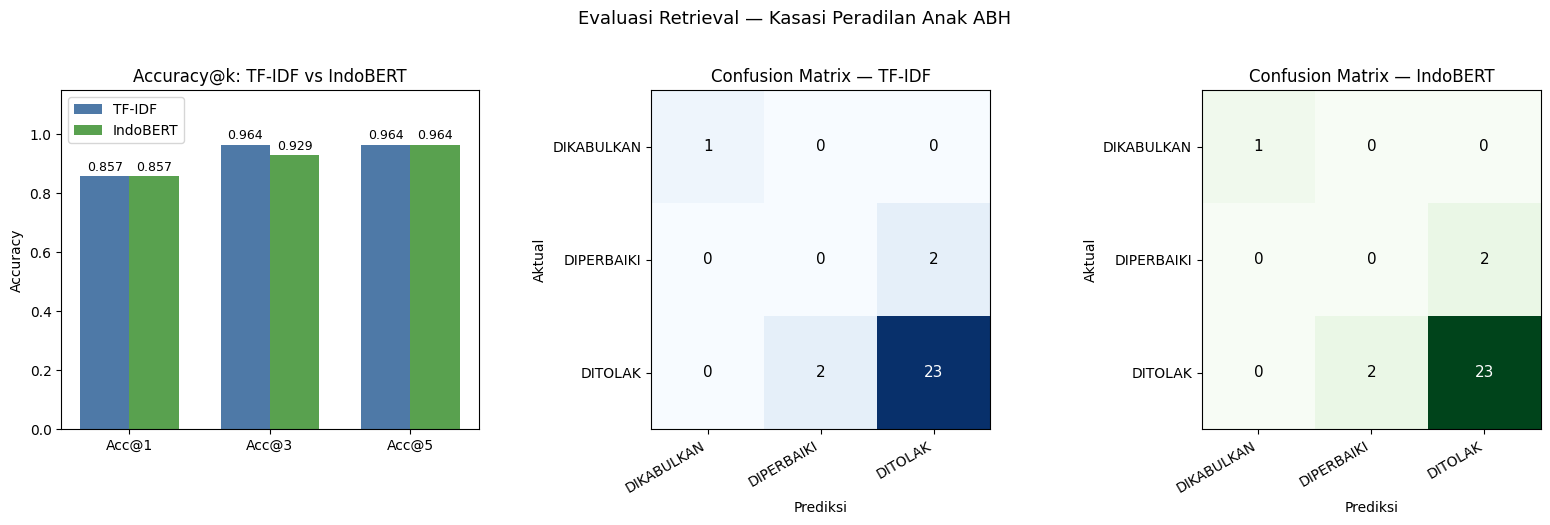

Grafik disimpan -> D:\Documents\SEMESTER6\Penalaran Komputer\Tugas 3(31)\data\retrieval_comparison.png


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Evaluasi Retrieval — Kasasi Peradilan Anak ABH', fontsize=13, y=1.02)

COLORS = ['#4e79a7', '#59a14f', '#f28e2b', '#e15759']

# ── Plot 1: Accuracy@k ────────────────────────────────────────────────
x, w = np.arange(3), 0.35
v_tfidf = [eval_tfidf['acc@1'], eval_tfidf['acc@3'], eval_tfidf['acc@5']]
v_bert  = [eval_bert['acc@1'],  eval_bert['acc@3'],  eval_bert['acc@5']]

b1 = axes[0].bar(x - w/2, v_tfidf, w, label='TF-IDF',   color=COLORS[0])
b2 = axes[0].bar(x + w/2, v_bert,  w, label='IndoBERT', color=COLORS[1])
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Acc@1', 'Acc@3', 'Acc@5'])
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Accuracy@k: TF-IDF vs IndoBERT')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

# ── Plot 2: Confusion Matrix TF-IDF ──────────────────────────────────
kelas = sorted(set(eval_tfidf['y_true']))
cm    = confusion_matrix(eval_tfidf['y_true'], eval_tfidf['y_pred'], labels=kelas)
im    = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks(range(len(kelas)))
axes[1].set_yticks(range(len(kelas)))
axes[1].set_xticklabels(kelas, rotation=30, ha='right')
axes[1].set_yticklabels(kelas)
axes[1].set_title('Confusion Matrix — TF-IDF')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')
for i in range(len(kelas)):
    for j in range(len(kelas)):
        axes[1].text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=11,
                     color='white' if cm[i,j] > cm.max()/2 else 'black')

# ── Plot 3: Confusion Matrix IndoBERT ────────────────────────────────
kelas_b = sorted(set(eval_bert['y_true']))
cm_b    = confusion_matrix(eval_bert['y_true'], eval_bert['y_pred'], labels=kelas_b)
axes[2].imshow(cm_b, cmap='Greens')
axes[2].set_xticks(range(len(kelas_b)))
axes[2].set_yticks(range(len(kelas_b)))
axes[2].set_xticklabels(kelas_b, rotation=30, ha='right')
axes[2].set_yticklabels(kelas_b)
axes[2].set_title('Confusion Matrix — IndoBERT')
axes[2].set_xlabel('Prediksi')
axes[2].set_ylabel('Aktual')
for i in range(len(kelas_b)):
    for j in range(len(kelas_b)):
        axes[2].text(j, i, str(cm_b[i,j]), ha='center', va='center', fontsize=11,
                     color='white' if cm_b[i,j] > cm_b.max()/2 else 'black')

plt.tight_layout()
plt.savefig(VIZ_DIR / 'retrieval_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafik disimpan -> {DATA_DIR / "retrieval_comparison.png"}')

## 11 · Simpan Hasil Retrieval

In [14]:
print('Menyimpan top-5 retrieval untuk setiap kasus (kedua metode) ...')

retrieval_results = []
for i, row in df.iterrows():
    entry = {
        'case_id'       : row['case_id'],
        'nomor_perkara' : row['nomor_perkara'],
        'outcome_kasasi': row['outcome_kasasi'],
        'top5_tfidf'    : retrieve_tfidf(row['teks_query'], top_k=5, exclude_idx=i),
        'top5_bert'     : retrieve_bert(row['teks_query'],  top_k=5, exclude_idx=i),
    }
    retrieval_results.append(entry)
    if (i + 1) % 10 == 0:
        print(f'  Proses {i+1}/{len(df)} kasus ...')

# ── Simpan JSON ───────────────────────────────────────────────────────
out_json = PROCESSED_DIR / 'retrieval_results.json'
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(retrieval_results, f, ensure_ascii=False, indent=2)
print(f'retrieval_results.json -> {out_json} ({len(retrieval_results)} entri)')

# ── Simpan CSV ringkas ────────────────────────────────────────────────
rows_csv = []
for entry in retrieval_results:
    for rank, (rt, rb) in enumerate(
        zip(entry['top5_tfidf'], entry['top5_bert']), 1
    ):
        rows_csv.append({
            'query_case_id': entry['case_id'],
            'rank'         : rank,
            'tfidf_case_id': rt['case_id'],
            'tfidf_outcome': rt['outcome_kasasi'],
            'tfidf_skor'   : rt['skor_similarity'],
            'bert_case_id' : rb['case_id'],
            'bert_outcome' : rb['outcome_kasasi'],
            'bert_skor'    : rb['skor_similarity'],
        })

out_csv = METRICS_DIR / 'retrieval_comparison.csv'
pd.DataFrame(rows_csv).to_csv(out_csv, index=False, encoding='utf-8-sig')
print(f'retrieval_comparison.csv -> {out_csv}')

print()
print('=== RINGKASAN OUTPUT NOTEBOOK 03 ===')
print(f'  data/processed/retrieval_results.json    ({len(retrieval_results)} entri, top-5 TF-IDF & BERT)')
print(f'  data/eval/metrics/retrieval_comparison.csv  (ringkasan per rank)')
print(f'  data/processed/bert_embeddings.npy       ({bert_matrix.shape})')
print(f'  data/eval/metrics/queries.json         ({len(queries_eval)} query uji)')
print(f'  data/eval/metrics/test_case_ids.json   ({len(test_case_ids)} kasus test set)')
print()
print('Lanjut ke : 04_case_reuse.ipynb')

Menyimpan top-5 retrieval untuk setiap kasus (kedua metode) ...
  Proses 10/150 kasus ...
  Proses 20/150 kasus ...
  Proses 30/150 kasus ...
  Proses 40/150 kasus ...
  Proses 50/150 kasus ...
  Proses 60/150 kasus ...
  Proses 70/150 kasus ...
  Proses 80/150 kasus ...
  Proses 90/150 kasus ...
  Proses 100/150 kasus ...
  Proses 110/150 kasus ...
  Proses 120/150 kasus ...
  Proses 130/150 kasus ...
  Proses 140/150 kasus ...
  Proses 150/150 kasus ...
retrieval_results.json -> D:\Documents\SEMESTER6\Penalaran Komputer\Tugas 3(31)\data\processed\retrieval_results.json (150 entri)
retrieval_comparison.csv -> D:\Documents\SEMESTER6\Penalaran Komputer\Tugas 3(31)\data\eval\metrics\retrieval_comparison.csv

=== RINGKASAN OUTPUT NOTEBOOK 03 ===
  data/processed/retrieval_results.json    (150 entri, top-5 TF-IDF & BERT)
  data/eval/metrics/retrieval_comparison.csv  (ringkasan per rank)
  data/processed/bert_embeddings.npy       ((150, 768))
  data/eval/metrics/queries.json         (10 que